# Toronto Neighbourhood Profiles — 2021 Census

This notebook loads the 2021 Census neighbourhood data for Toronto's 158 neighbourhoods and generates a comprehensive set of charts for each one. All charts are saved as PNG files organized by neighbourhood name.

**Charts generated per neighbourhood:**
1. Age Distribution (bar chart)
2. Household Income Distribution (horizontal bar)
3. Dwelling Types (pie chart)
4. Visible Minority Breakdown (horizontal bar)
5. Education Attainment (donut chart)
6. Labour Force Status (pie chart)
7. Owner vs Renter vs Other (pie chart)
8. Household Size Distribution (bar chart)
9. Key Stats Summary Card (text figure)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

TORONTO_RED   = '#c8102e'
TORONTO_BLUE  = '#003da5'
PALETTE = ['#003da5','#c8102e','#f7a800','#00843d','#7b2d8b','#e87722','#009bde','#6d6e71']

print('Libraries loaded ✓')

Libraries loaded ✓


In [8]:
# ── Load & structure data ──────────────────────────────────────────────────────
FILE = './data/neighbourhoods/neighbourhood-profiles-2021-158-model.xlsx'

raw = pd.read_excel(FILE, header=None)

# Row 0 = neighbourhood names, columns 1–158
neighbourhood_names = raw.iloc[0, 1:].tolist()
n_hoods = len(neighbourhood_names)

# Helper: get a single row's values across all neighbourhoods as a Series
def row(idx):
    vals = pd.to_numeric(raw.iloc[idx, 1:], errors='coerce')
    vals.index = neighbourhood_names
    return vals

print(f'Loaded {n_hoods} neighbourhoods  |  {raw.shape[0]} data rows')
print('Sample names:', neighbourhood_names[:5])

Loaded 158 neighbourhoods  |  2604 data rows
Sample names: ['West Humber-Clairville', 'Mount Olive-Silverstone-Jamestown', 'Thistletown-Beaumond Heights', 'Rexdale-Kipling', 'Elms-Old Rexdale']


In [9]:
# ── Pre-extract all needed rows ────────────────────────────────────────────────

# AGE GROUPS (absolute counts)
age_labels = ['0–14', '15–24', '25–34', '35–44', '45–54', '55–64', '65+']
age_rows   = [4, 9, 11, 13, 15, 17, 19]   # row indices
age_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(age_labels, age_rows)})

# INCOME GROUPS (household)
income_labels = ['<$20k','$20-40k','$40-60k','$60-80k','$80-100k','$100k+']
income_rows   = [259+260, 262+263, 269, 270, 271, 274]  # approximate — redefined below

hh_income_labels = ['Under $20k','$20k–$40k','$40k–$60k','$60k–$80k','$80k–$100k','$100k+']
hh_income_rows   = {
    'Under $20k': [259, 260, 261, 262],
    '$20k–$40k':  [263, 264, 265, 266],
    '$40k–$60k':  [267, 268, 269],
    '$60k–$80k':  [270, 271],
    '$80k–$100k': [272, 273],
    '$100k+':     [274],
}

hh_income_data = {}
for lbl, rows_list in hh_income_rows.items():
    combined = sum(row(r) for r in rows_list)
    hh_income_data[lbl] = combined
hh_income_df = pd.DataFrame(hh_income_data)

# DWELLING TYPES
dwelling_labels = ['Single detached','Semi-detached','Row house','Duplex apt','Low-rise apt','High-rise apt','Other']
dwelling_rows   = [217, 218, 219, 220, 221, 222, 223]
dwelling_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(dwelling_labels, dwelling_rows)})

# VISIBLE MINORITY
vm_labels = ['South Asian','Chinese','Black','Filipino','Arab','Latin American','SE Asian','West Asian','Korean','Japanese','Other VM']
vm_rows   = [1643,1644,1645,1646,1647,1648,1649,1650,1651,1652,1653]
vm_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(vm_labels, vm_rows)})
not_vm    = row(1655)

# EDUCATION
edu_labels = ['No cert/diploma','High school','Trades/College','University <Bach.','Bachelor+'] 
edu_rows   = [1982, 1983, 1985, 1990, 1991]
edu_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(edu_labels, edu_rows)})

# LABOUR FORCE
lf_labels = ['Employed','Unemployed','Not in labour force']
lf_rows   = [1966, 1967, 1968]
lf_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(lf_labels, lf_rows)})

# TENURE
tenure_labels = ['Owner','Renter','Gov provided']
tenure_rows   = [300, 301, 302]
tenure_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(tenure_labels, tenure_rows)})

# HOUSEHOLD SIZE
hhsize_labels = ['1 person','2 persons','3 persons','4 persons','5+ persons']
hhsize_rows   = [226, 227, 228, 229, 230]
hhsize_data   = pd.DataFrame({lbl: row(r) for lbl, r in zip(hhsize_labels, hhsize_rows)})

# KEY STATS (single values per neighbourhood)
stat_median_hh_income  = row(244)   # Median household total income 2020
stat_median_age        = row(35)
stat_population        = row(3)
stat_unemployment_rate = row(1971)
stat_avg_hh_size       = row(231)
stat_pct_immigrants    = row(1642) / row(1641) * 100   # visible minority %

print('All data pre-extracted ✓')

All data pre-extracted ✓


In [12]:
# ── Chart helper functions ─────────────────────────────────────────────────────

def safe_pct(values):
    """Convert raw counts to percentages, handling zero totals."""
    total = values.sum()
    return (values / total * 100) if total > 0 else values * 0


def plot_age_distribution(hood, ax):
    vals = age_data.loc[hood].fillna(0)
    pcts = safe_pct(vals)
    bars = ax.bar(age_labels, pcts, color=TORONTO_BLUE, edgecolor='white', linewidth=0.5)
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)
    ax.set_title('Age Distribution', fontweight='bold', fontsize=11)
    ax.set_ylabel('% of Population')
    ax.set_ylim(0, pcts.max() * 1.2 + 2)


def plot_income_distribution(hood, ax):
    vals = hh_income_df.loc[hood].fillna(0)
    pcts = safe_pct(vals)
    colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(hh_income_labels)))
    bars = ax.barh(hh_income_labels, pcts, color=colors, edgecolor='white')
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{pct:.1f}%', va='center', fontsize=7)
    ax.set_title('Household Income Distribution', fontweight='bold', fontsize=11)
    ax.set_xlabel('% of Households')
    ax.set_xlim(0, pcts.max() * 1.25 + 2)


def plot_dwelling_types(hood, ax):
    vals = dwelling_data.loc[hood].fillna(0)
    non_zero = vals[vals > 0]
    if non_zero.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Dwelling Types', fontweight='bold', fontsize=11)
        return
    wedges, texts, autotexts = ax.pie(
        non_zero, labels=non_zero.index, autopct='%1.1f%%',
        colors=PALETTE[:len(non_zero)], startangle=140,
        pctdistance=0.75, labeldistance=1.1,
        textprops={'fontsize': 7}
    )
    for at in autotexts:
        at.set_fontsize(6.5)
    ax.set_title('Dwelling Types', fontweight='bold', fontsize=11)


def plot_visible_minority(hood, ax):
    vm_vals = vm_data.loc[hood].fillna(0)
    not_vm_val = not_vm[hood] if not pd.isna(not_vm[hood]) else 0
    total = vm_vals.sum() + not_vm_val
    if total == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Population Diversity', fontweight='bold', fontsize=11)
        return
    vm_pcts = vm_vals / total * 100
    vm_pcts_sorted = vm_pcts[vm_pcts > 0.5].sort_values(ascending=True)
    not_vm_pct = not_vm_val / total * 100
    
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vm_pcts_sorted))]
    bars = ax.barh(vm_pcts_sorted.index, vm_pcts_sorted, color=colors, edgecolor='white')
    for bar, pct in zip(bars, vm_pcts_sorted):
        ax.text(pct + 0.2, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=7)
    ax.set_title(f'Visible Minority Groups  (Not VM: {not_vm_pct:.1f}%)', fontweight='bold', fontsize=10)
    ax.set_xlabel('% of Population')
    ax.set_xlim(0, vm_pcts_sorted.max() * 1.25 + 2)


def plot_education(hood, ax):
    vals = edu_data.loc[hood].fillna(0)
    non_zero = vals[vals > 0]
    if non_zero.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Education Attainment', fontweight='bold', fontsize=11)
        return
    edu_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#003da5']
    wedges, texts, autotexts = ax.pie(
        non_zero, labels=non_zero.index, autopct='%1.1f%%',
        colors=edu_colors[:len(non_zero)], startangle=90,
        wedgeprops={'width': 0.55}, pctdistance=0.75,
        textprops={'fontsize': 7}
    )
    for at in autotexts:
        at.set_fontsize(6.5)
    ax.set_title('Education Attainment (15+)', fontweight='bold', fontsize=11)


def plot_labour_force(hood, ax):
    vals = lf_data.loc[hood].fillna(0)
    non_zero = vals[vals > 0]
    if non_zero.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Labour Force Status', fontweight='bold', fontsize=11)
        return
    lf_colors = ['#00843d','#c8102e','#6d6e71']
    wedges, texts, autotexts = ax.pie(
        non_zero, labels=non_zero.index, autopct='%1.1f%%',
        colors=lf_colors[:len(non_zero)], startangle=140,
        textprops={'fontsize': 8}
    )
    for at in autotexts:
        at.set_fontsize(7.5)
    ax.set_title('Labour Force Status (15+)', fontweight='bold', fontsize=11)


def plot_tenure(hood, ax):
    vals = tenure_data.loc[hood].fillna(0)
    non_zero = vals[vals > 0]
    if non_zero.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Housing Tenure', fontweight='bold', fontsize=11)
        return
    t_colors = [TORONTO_BLUE, TORONTO_RED, '#f7a800']
    wedges, texts, autotexts = ax.pie(
        non_zero, labels=non_zero.index, autopct='%1.1f%%',
        colors=t_colors[:len(non_zero)], startangle=90,
        textprops={'fontsize': 8}
    )
    for at in autotexts:
        at.set_fontsize(7.5)
    ax.set_title('Housing Tenure', fontweight='bold', fontsize=11)


def plot_household_size(hood, ax):
    vals = hhsize_data.loc[hood].fillna(0)
    pcts = safe_pct(vals)
    colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(hhsize_labels)))
    bars = ax.bar(hhsize_labels, pcts, color=colors, edgecolor='white')
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)
    ax.set_title('Household Size', fontweight='bold', fontsize=11)
    ax.set_ylabel('% of Households')
    ax.set_ylim(0, pcts.max() * 1.2 + 2)


def plot_summary_card(hood, ax):
    ax.axis('off')
    med_income = stat_median_hh_income[hood]
    med_age    = stat_median_age[hood]
    population = stat_population[hood]
    unemp      = stat_unemployment_rate[hood]
    avg_size   = stat_avg_hh_size[hood]
    vm_pct     = stat_pct_immigrants[hood]
    
    def fmt(val, prefix='', suffix='', decimals=0):
        if pd.isna(val): return 'N/A'
        return f"{prefix}{val:,.{decimals}f}{suffix}"
    
    stats = [
        ('Population',              fmt(population)),
        ('Median Household Income', fmt(med_income, prefix='$')),
        ('Median Age',              fmt(med_age, suffix=' yrs', decimals=1)),
        ('Unemployment Rate',       fmt(unemp, suffix='%', decimals=1)),
        ('Avg Household Size',      fmt(avg_size, decimals=2)),
        ('Visible Minority %',      fmt(vm_pct, suffix='%', decimals=1)),
    ]
    
    ax.add_patch(mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
        boxstyle='round,pad=0.02', facecolor='#f0f4ff', edgecolor=TORONTO_BLUE, linewidth=2,
        transform=ax.transAxes))
    ax.text(0.5, 0.93, '📊 Key Statistics', ha='center', va='top',
            fontsize=13, fontweight='bold', color=TORONTO_BLUE, transform=ax.transAxes)
    
    for i, (label, value) in enumerate(stats):
        y = 0.78 - i * 0.125
        ax.text(0.08, y, label, ha='left', va='center', fontsize=9,
                color='#555555', transform=ax.transAxes)
        ax.text(0.92, y, value, ha='right', va='center', fontsize=10,
                fontweight='bold', color=TORONTO_BLUE, transform=ax.transAxes)
        line = plt.Line2D([0.05, 0.95], [y - 0.05, y - 0.05], color='#cccccc', linewidth=0.5, transform=ax.transAxes)
        ax.add_line(line)

print('Chart helper functions defined ✓')

Chart helper functions defined ✓


In [13]:
# ── Generate charts for ALL neighbourhoods ─────────────────────────────────────
OUTPUT_DIR = 'neighbourhood_charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for idx, hood in enumerate(neighbourhood_names):
    # Create safe folder name
    safe_name = hood.replace('/', '-').replace(' ', '_')
    hood_dir = os.path.join(OUTPUT_DIR, safe_name)
    os.makedirs(hood_dir, exist_ok=True)
    
    # ── 3×3 master figure ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle(f'{hood}  —  2021 Census Profile',
                 fontsize=18, fontweight='bold', color=TORONTO_BLUE, y=0.98)
    fig.patch.set_facecolor('#fafafa')
    for ax in axes.flat:
        ax.set_facecolor('white')
    
    plot_summary_card(hood,          axes[0, 0])
    plot_age_distribution(hood,      axes[0, 1])
    plot_income_distribution(hood,   axes[0, 2])
    plot_dwelling_types(hood,        axes[1, 0])
    plot_visible_minority(hood,      axes[1, 1])
    plot_education(hood,             axes[1, 2])
    plot_labour_force(hood,          axes[2, 0])
    plot_tenure(hood,                axes[2, 1])
    plot_household_size(hood,        axes[2, 2])
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    master_path = os.path.join(hood_dir, 'overview.png')
    fig.savefig(master_path, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    
    # ── Individual charts ──────────────────────────────────────────────────────
    chart_funcs = [
        ('age_distribution',    plot_age_distribution),
        ('income_distribution', plot_income_distribution),
        ('dwelling_types',      plot_dwelling_types),
        ('visible_minority',    plot_visible_minority),
        ('education',           plot_education),
        ('labour_force',        plot_labour_force),
        ('housing_tenure',      plot_tenure),
        ('household_size',      plot_household_size),
    ]
    
    for chart_name, func in chart_funcs:
        fig2, ax2 = plt.subplots(figsize=(7, 5))
        fig2.patch.set_facecolor('white')
        ax2.set_facecolor('white')
        func(hood, ax2)
        plt.tight_layout()
        fig2.savefig(os.path.join(hood_dir, f'{chart_name}.png'),
                     dpi=130, bbox_inches='tight')
        plt.close(fig2)
    
    if (idx + 1) % 20 == 0 or idx == 0:
        print(f'  [{idx+1}/{n_hoods}] {hood} ✓')

print(f'\n✅ Done! Charts saved to: {OUTPUT_DIR}/')
print(f'   {n_hoods} neighbourhoods × {len(chart_funcs)+1} charts = {n_hoods*(len(chart_funcs)+1)} total files')

  [1/158] West Humber-Clairville ✓
  [20/158] Humbermede ✓
  [40/158] Victoria Village ✓
  [60/158] Greenwood-Coxwell ✓
  [80/158] Runnymede-Bloor West Village ✓
  [100/158] Rockcliffe-Smythe ✓
  [120/158] Morningside ✓
  [140/158] Bendale-Glen Andrew ✓

✅ Done! Charts saved to: neighbourhood_charts/
   158 neighbourhoods × 9 charts = 1422 total files


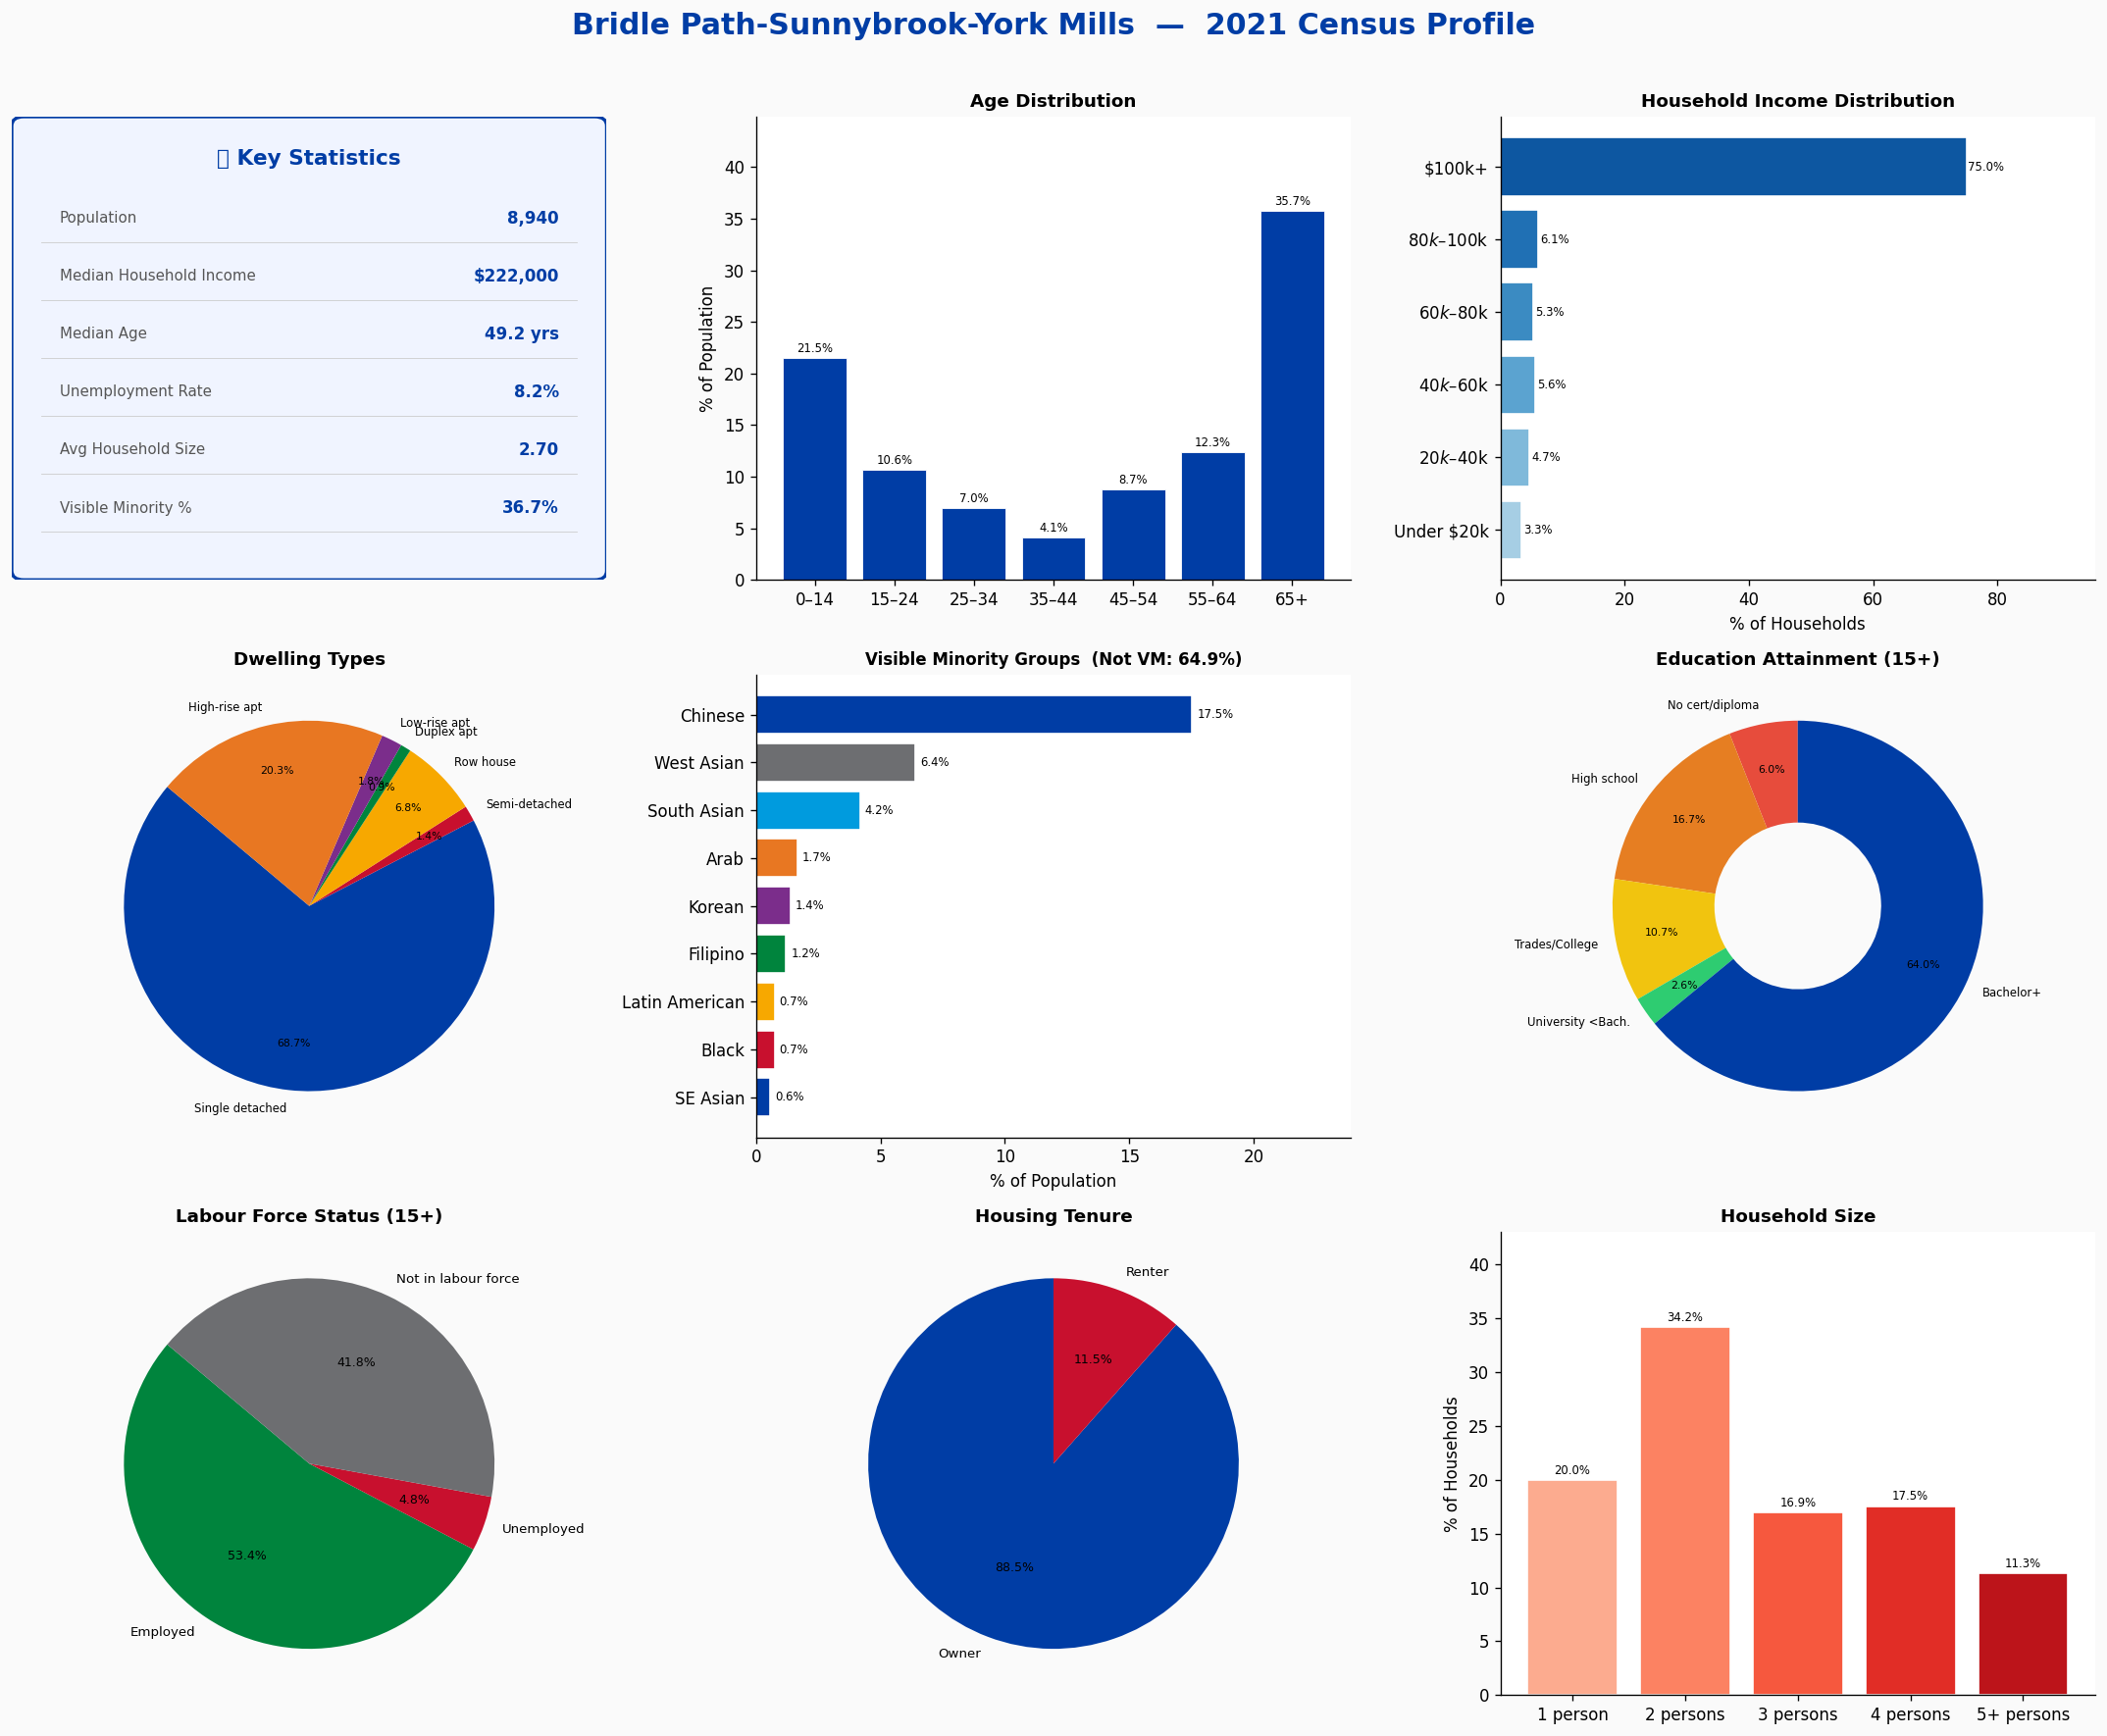

In [17]:
# ── Preview one neighbourhood inline ──────────────────────────────────────────
PREVIEW_HOOD = 'Bridle Path-Sunnybrook-York Mills'   # ← Change to any neighbourhood name

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle(f'{PREVIEW_HOOD}  —  2021 Census Profile',
             fontsize=18, fontweight='bold', color=TORONTO_BLUE, y=0.98)
fig.patch.set_facecolor('#fafafa')
for ax in axes.flat:
    ax.set_facecolor('white')

plot_summary_card(PREVIEW_HOOD,          axes[0, 0])
plot_age_distribution(PREVIEW_HOOD,      axes[0, 1])
plot_income_distribution(PREVIEW_HOOD,   axes[0, 2])
plot_dwelling_types(PREVIEW_HOOD,        axes[1, 0])
plot_visible_minority(PREVIEW_HOOD,      axes[1, 1])
plot_education(PREVIEW_HOOD,             axes[1, 2])
plot_labour_force(PREVIEW_HOOD,          axes[2, 0])
plot_tenure(PREVIEW_HOOD,                axes[2, 1])
plot_household_size(PREVIEW_HOOD,        axes[2, 2])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

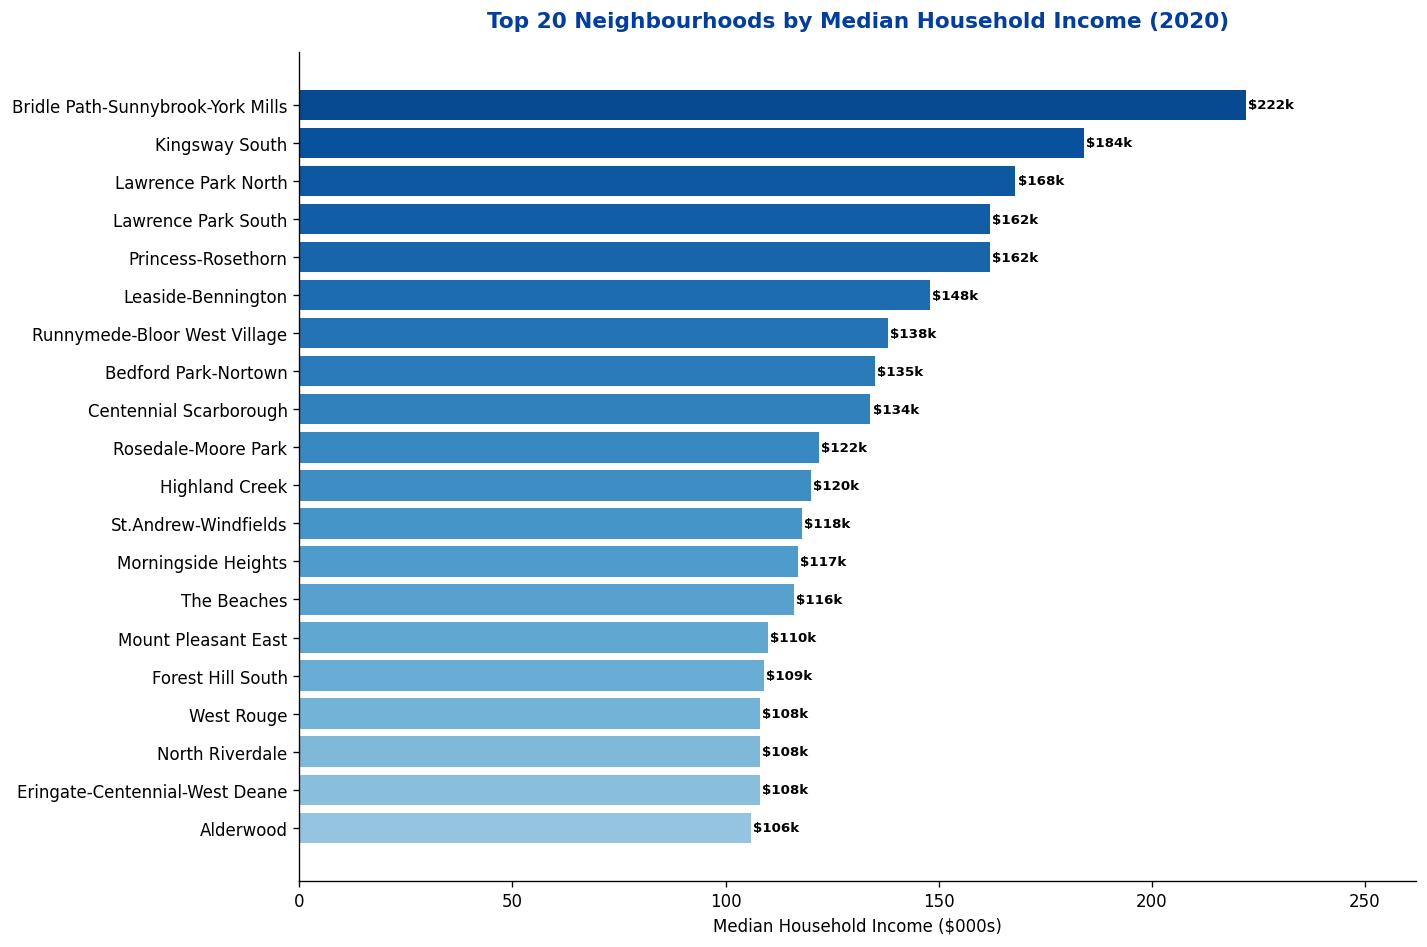

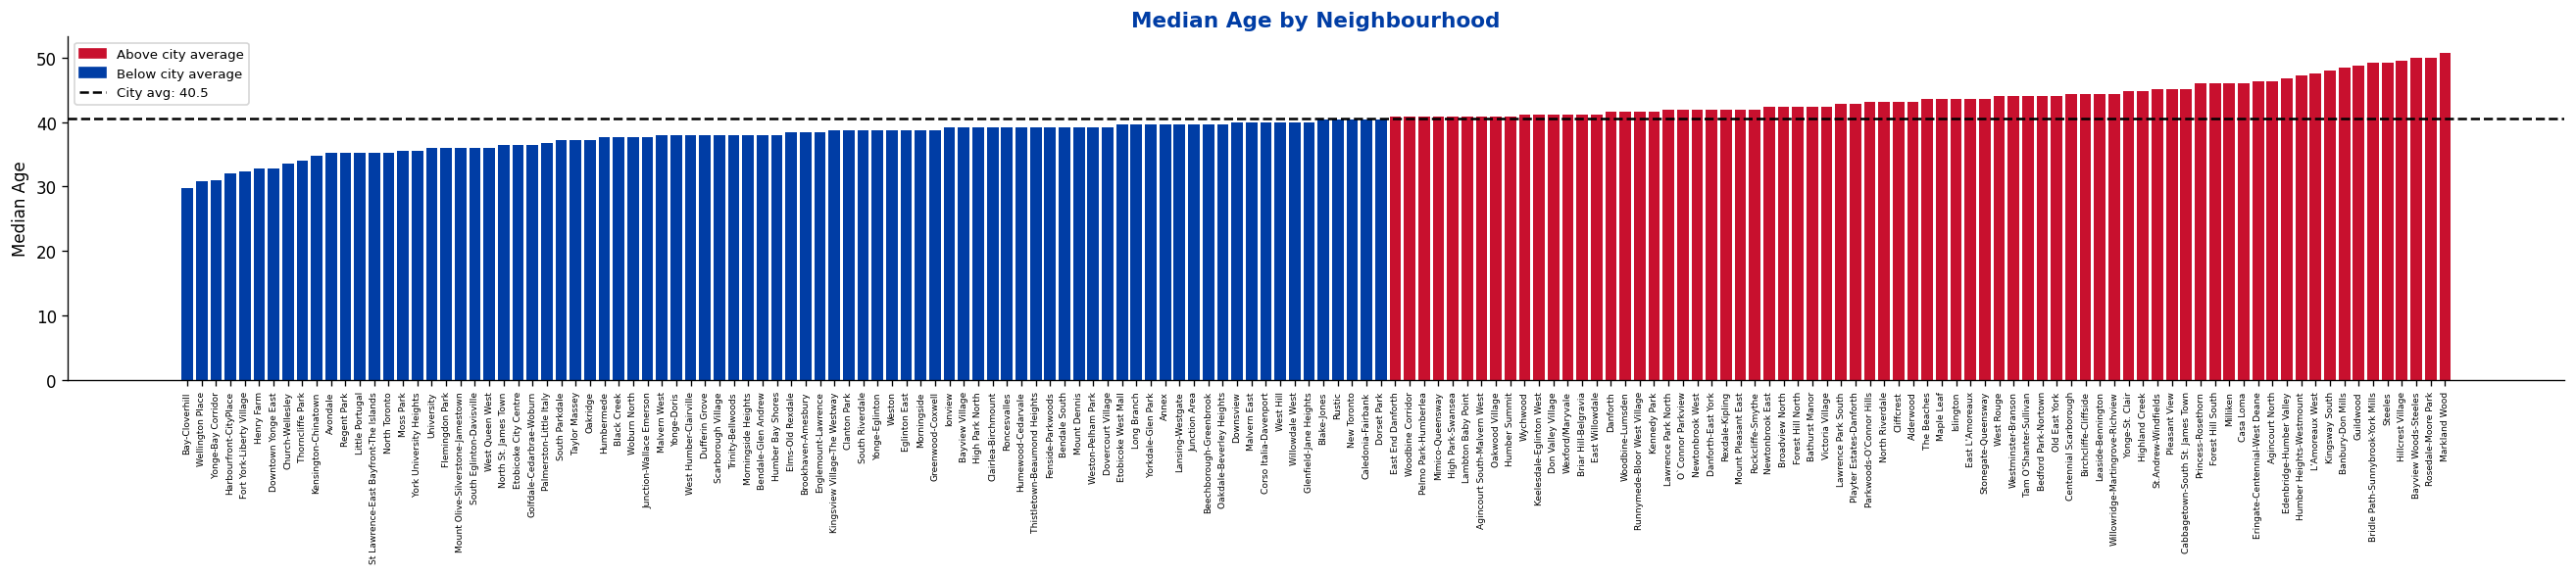

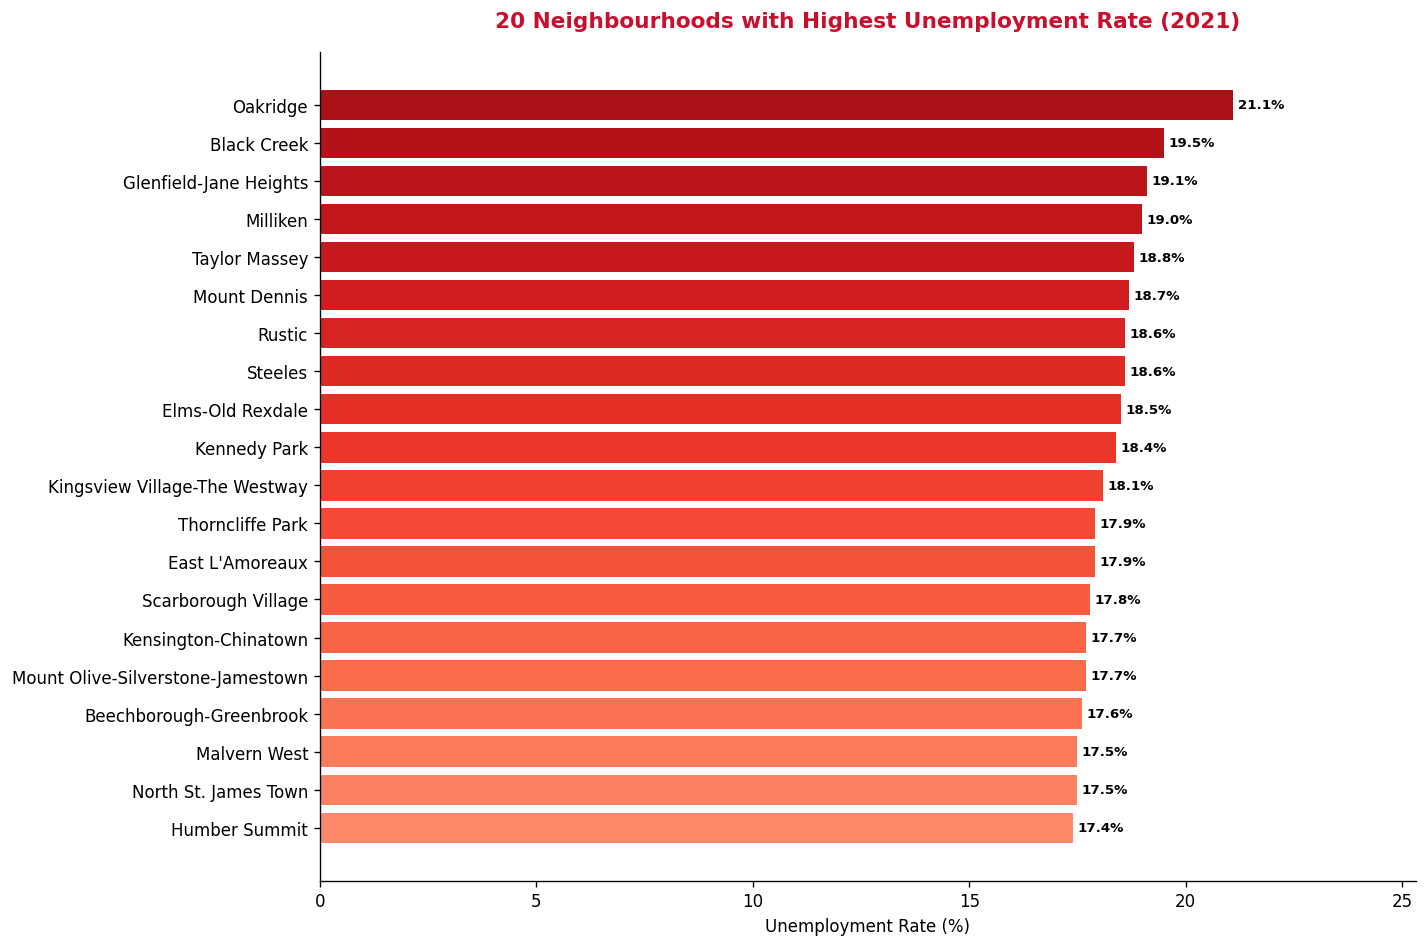

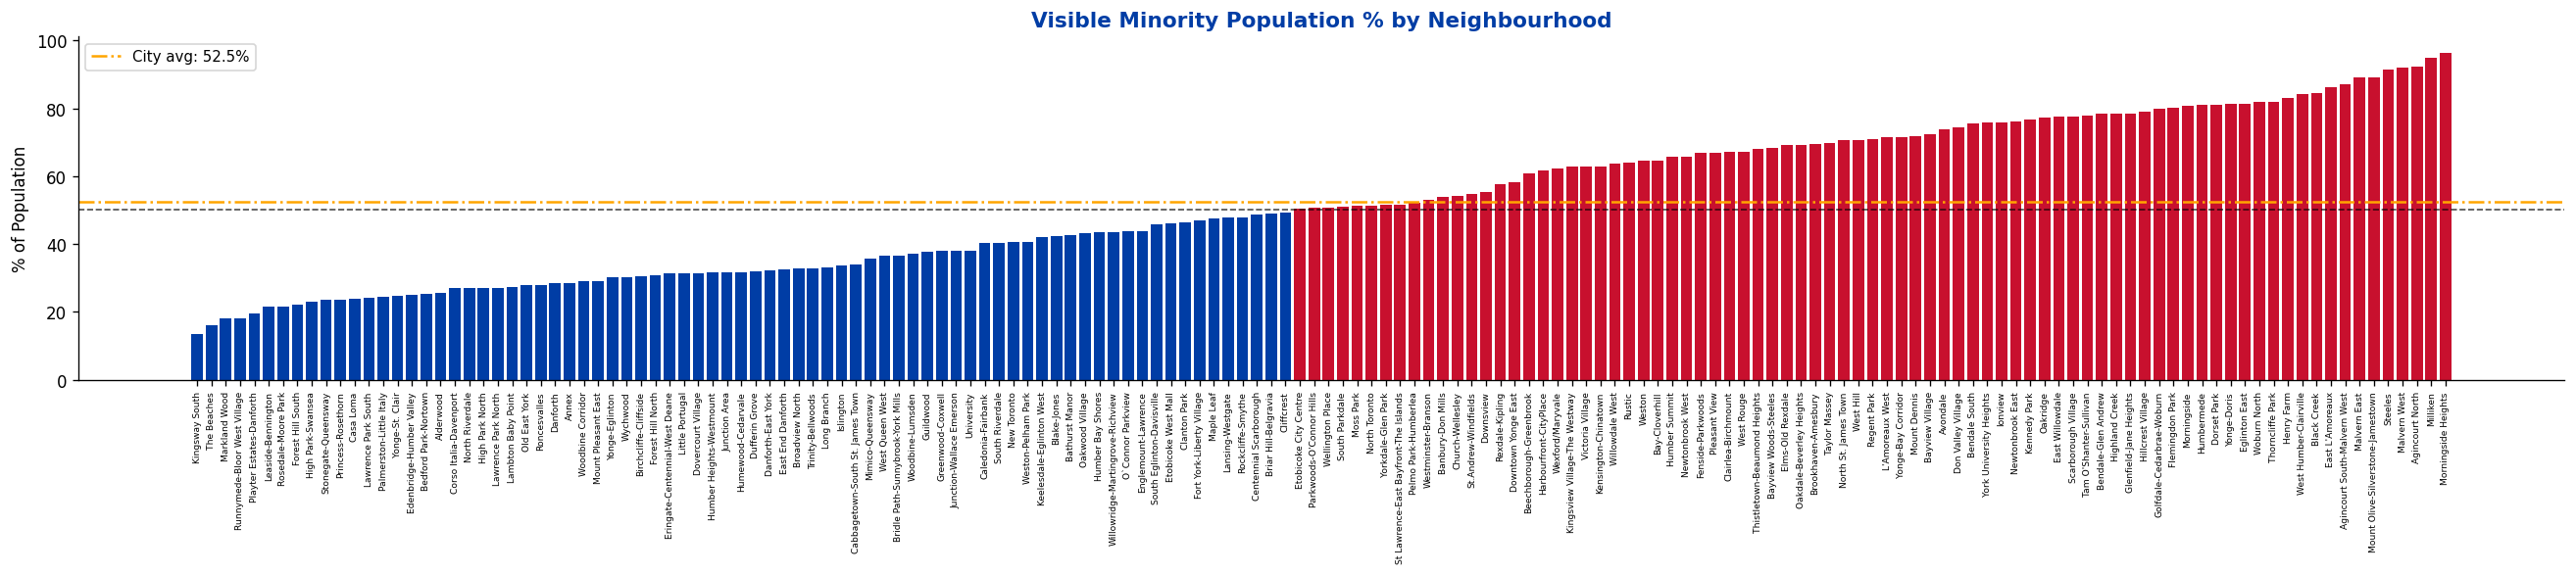


✅ City-wide comparison charts saved!


In [15]:
# ── City-wide comparison charts ───────────────────────────────────────────────
os.makedirs(os.path.join(OUTPUT_DIR, '_city_wide'), exist_ok=True)
city_dir = os.path.join(OUTPUT_DIR, '_city_wide')

# 1. Top 20 neighbourhoods by median household income
fig, ax = plt.subplots(figsize=(12, 8))
top20_income = stat_median_hh_income.dropna().sort_values(ascending=True).tail(20)
colors_grad = plt.cm.Blues(np.linspace(0.4, 0.9, 20))
bars = ax.barh(top20_income.index, top20_income / 1000, color=colors_grad)
for bar, val in zip(bars, top20_income):
    ax.text(val/1000 + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}k', va='center', fontsize=8, fontweight='bold')
ax.set_title('Top 20 Neighbourhoods by Median Household Income (2020)',
             fontsize=13, fontweight='bold', color=TORONTO_BLUE, pad=15)
ax.set_xlabel('Median Household Income ($000s)')
ax.set_xlim(0, top20_income.max()/1000 * 1.18)
plt.tight_layout()
fig.savefig(os.path.join(city_dir, 'top20_income.png'), dpi=130, bbox_inches='tight')
plt.show()

# 2. Median age across all neighbourhoods (sorted)
fig, ax = plt.subplots(figsize=(22, 5))
med_age_sorted = stat_median_age.dropna().sort_values()
x_pos = np.arange(len(med_age_sorted))
city_avg = med_age_sorted.mean()
colors_age = [TORONTO_RED if v > city_avg else TORONTO_BLUE for v in med_age_sorted]
ax.bar(x_pos, med_age_sorted, color=colors_age, width=0.8)
ax.axhline(city_avg, color='black', linewidth=1.5, linestyle='--', label=f'City avg: {city_avg:.1f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(med_age_sorted.index, rotation=90, fontsize=5.5)
ax.set_title('Median Age by Neighbourhood', fontsize=13, fontweight='bold', color=TORONTO_BLUE)
ax.set_ylabel('Median Age')
ax.legend()
red_patch = mpatches.Patch(color=TORONTO_RED, label='Above city average')
blue_patch = mpatches.Patch(color=TORONTO_BLUE, label='Below city average')
ax.legend(handles=[red_patch, blue_patch, ax.lines[0]], fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(city_dir, 'median_age_all.png'), dpi=130, bbox_inches='tight')
plt.show()

# 3. Unemployment rate — bottom 20 (highest unemployment)
fig, ax = plt.subplots(figsize=(12, 8))
worst20_unemp = stat_unemployment_rate.dropna().sort_values(ascending=False).head(20).sort_values()
colors_u = plt.cm.Reds(np.linspace(0.4, 0.85, 20))
bars = ax.barh(worst20_unemp.index, worst20_unemp, color=colors_u)
for bar, val in zip(bars, worst20_unemp):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
ax.set_title('20 Neighbourhoods with Highest Unemployment Rate (2021)',
             fontsize=13, fontweight='bold', color=TORONTO_RED, pad=15)
ax.set_xlabel('Unemployment Rate (%)')
ax.set_xlim(0, worst20_unemp.max() * 1.2)
plt.tight_layout()
fig.savefig(os.path.join(city_dir, 'top20_unemployment.png'), dpi=130, bbox_inches='tight')
plt.show()

# 4. Visible minority % across all neighbourhoods
fig, ax = plt.subplots(figsize=(22, 5))
vm_pct_all = (row(1642) / row(1641) * 100).dropna().sort_values()
x_pos = np.arange(len(vm_pct_all))
city_vm_avg = vm_pct_all.mean()
colors_vm = [TORONTO_RED if v > 50 else TORONTO_BLUE for v in vm_pct_all]
ax.bar(x_pos, vm_pct_all, color=colors_vm, width=0.8)
ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(city_vm_avg, color='orange', linewidth=1.5, linestyle='-.', label=f'City avg: {city_vm_avg:.1f}%')
ax.set_xticks(x_pos)
ax.set_xticklabels(vm_pct_all.index, rotation=90, fontsize=5.5)
ax.set_title('Visible Minority Population % by Neighbourhood', fontsize=13, fontweight='bold', color=TORONTO_BLUE)
ax.set_ylabel('% of Population')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(city_dir, 'visible_minority_all.png'), dpi=130, bbox_inches='tight')
plt.show()

print('\n✅ City-wide comparison charts saved!')

In [18]:
# ── Print all neighbourhood names for reference ────────────────────────────────
print('All 158 Toronto Neighbourhoods:')
print('=' * 60)
for i, name in enumerate(sorted(neighbourhood_names), 1):
    print(f'{i:>3}. {name}')

All 158 Toronto Neighbourhoods:
  1. Agincourt North
  2. Agincourt South-Malvern West
  3. Alderwood
  4. Annex
  5. Avondale
  6. Banbury-Don Mills
  7. Bathurst Manor
  8. Bay-Cloverhill
  9. Bayview Village
 10. Bayview Woods-Steeles
 11. Bedford Park-Nortown
 12. Beechborough-Greenbrook
 13. Bendale South
 14. Bendale-Glen Andrew
 15. Birchcliffe-Cliffside
 16. Black Creek
 17. Blake-Jones
 18. Briar Hill-Belgravia
 19. Bridle Path-Sunnybrook-York Mills
 20. Broadview North
 21. Brookhaven-Amesbury
 22. Cabbagetown-South St. James Town
 23. Caledonia-Fairbank
 24. Casa Loma
 25. Centennial Scarborough
 26. Church-Wellesley
 27. Clairlea-Birchmount
 28. Clanton Park
 29. Cliffcrest
 30. Corso Italia-Davenport
 31. Danforth
 32. Danforth-East York
 33. Don Valley Village
 34. Dorset Park
 35. Dovercourt Village
 36. Downsview
 37. Downtown Yonge East
 38. Dufferin Grove
 39. East End Danforth
 40. East L'Amoreaux
 41. East Willowdale
 42. Edenbridge-Humber Valley
 43. Eglinton East


# Generate neighbourhood map

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file('./data/neighbourhoods/neighbourhoods.geojson')

In [21]:
print(gdf.columns.tolist())

['_id', 'AREA_ID', 'AREA_ATTR_ID', 'PARENT_AREA_ID', 'AREA_SHORT_CODE', 'AREA_LONG_CODE', 'AREA_NAME', 'AREA_DESC', 'CLASSIFICATION', 'CLASSIFICATION_CODE', 'OBJECTID', 'geometry']


In [97]:
hood = "Annex"

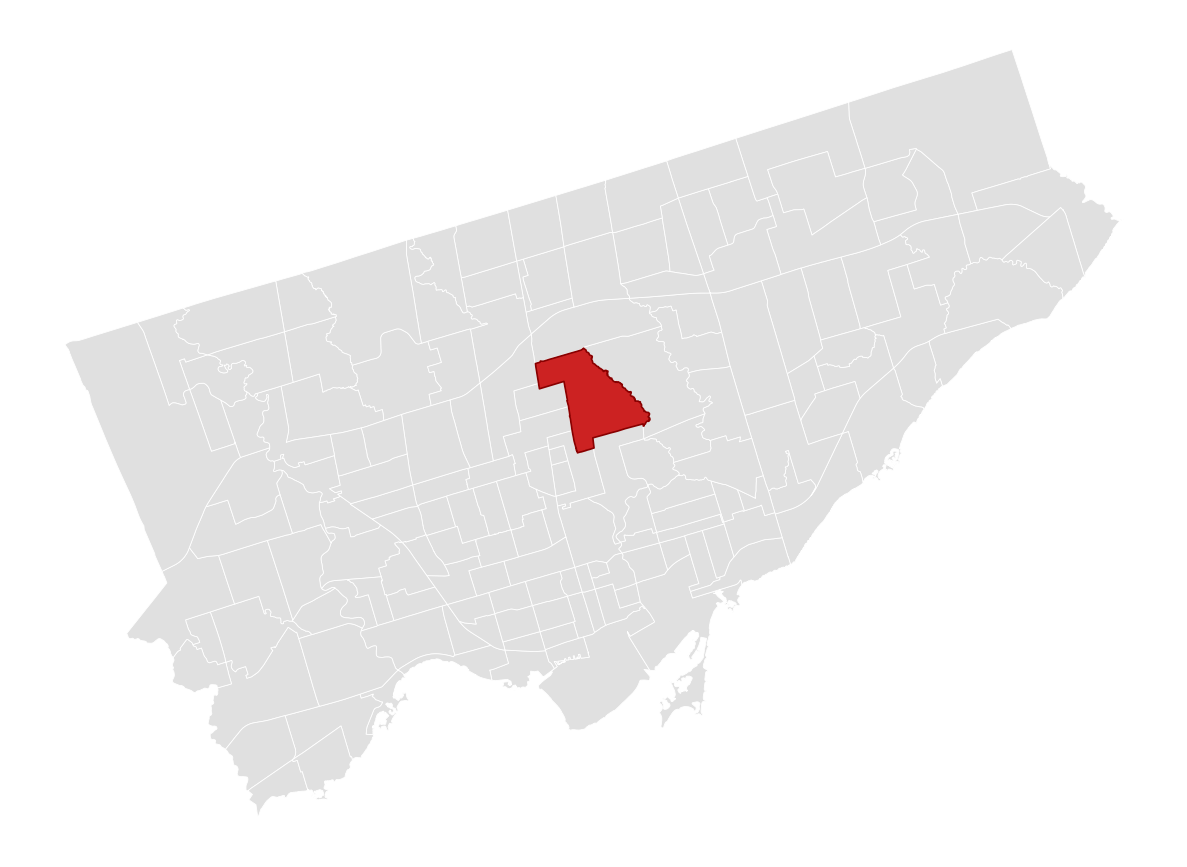

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')

gdf.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.5)

gdf[gdf["AREA_NAME"] == hood].plot(
    ax=ax,
    color="#cc2222",
    edgecolor="#880000",
    linewidth=1
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{hood}_map.png", dpi=150, bbox_inches="tight")
plt.show()

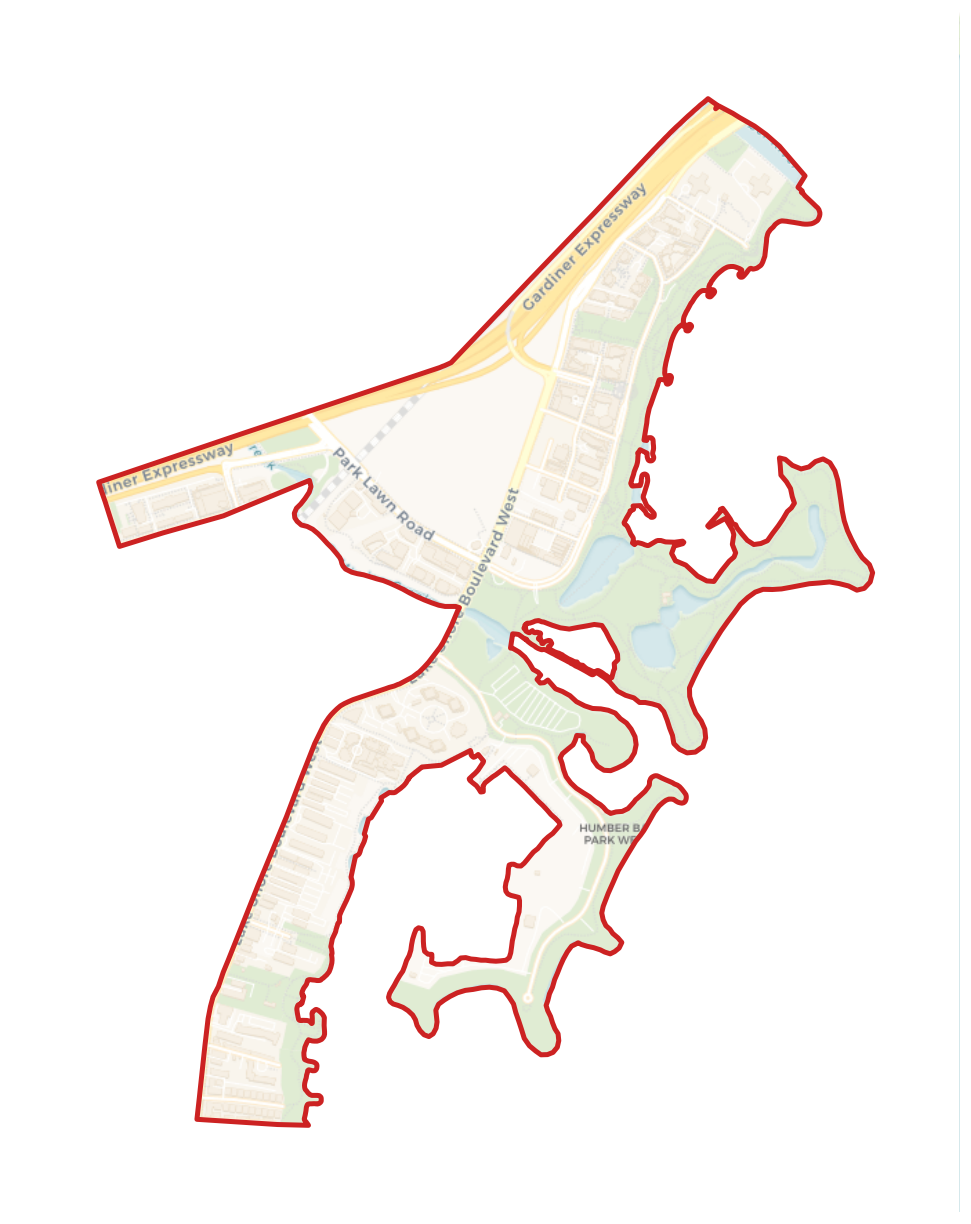

In [62]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import numpy as np

target = gdf[gdf["AREA_NAME"] == hood].to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_facecolor("white")

target.plot(ax=ax, color="#fff8f8", edgecolor="none", zorder=1)

bounds = target.total_bounds
pad = 300
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=15, zorder=2)

# ── Opaque mask using PathPatch (no descartes needed) ─────────────────────
geom = target.geometry.iloc[0]
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
big_box = box(xmin - 1000, ymin - 1000, xmax + 1000, ymax + 1000)
mask_geom = big_box.difference(geom)

def geom_to_path(geom):
    """Convert a shapely polygon (with holes) to a matplotlib Path."""
    vertices, codes = [], []
    # Exterior ring
    exterior = np.array(geom.exterior.coords)
    vertices.append(exterior)
    codes.append([Path.MOVETO] + [Path.LINETO] * (len(exterior) - 2) + [Path.CLOSEPOLY])
    # Interior rings (holes)
    for interior in geom.interiors:
        coords = np.array(interior.coords)
        vertices.append(coords)
        codes.append([Path.MOVETO] + [Path.LINETO] * (len(coords) - 2) + [Path.CLOSEPOLY])
    return Path(np.concatenate(vertices), np.concatenate(codes))

path = geom_to_path(mask_geom)
patch = PathPatch(path, facecolor="white", edgecolor="white", linewidth=0, zorder=3)
ax.add_patch(patch)

# Red outline on top
target.plot(ax=ax, color="none", edgecolor="#cc2222", linewidth=3, zorder=4)

ax.margins(0)
ax.set_axis_off()
plt.tight_layout(pad=0)
plt.savefig(f"{hood}_map.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# Generate neighbourhood vs Toronto comparison charts

In [63]:
# ══════════════════════════════════════════════════════════════════════════════
# TORONTO CITY-WIDE STATS
# Derived from the 158 neighbourhood columns in the Excel sheet.
# ══════════════════════════════════════════════════════════════════════════════

def _city_sum(row):
    return pd.to_numeric(raw.iloc[row, 1:], errors='coerce').sum()

def _city_mean(row):
    return pd.to_numeric(raw.iloc[row, 1:], errors='coerce').mean()

def _weighted_median(val_row, weight_row):
    vals    = pd.to_numeric(raw.iloc[val_row,    1:], errors='coerce')
    weights = pd.to_numeric(raw.iloc[weight_row, 1:], errors='coerce')
    mask = vals.notna() & weights.notna() & (weights > 0)
    return round((vals[mask] * weights[mask]).sum() / weights[mask].sum())

_tor_pop        = _city_sum(3)
_tor_mt_total   = _city_sum(437)
_tor_imm_total  = _city_sum(1485)
_tor_gen_total  = _city_sum(1623)
_tor_vis_total  = _city_sum(1641)
_tor_ind_total  = _city_sum(1446)
_tor_cit_total  = _city_sum(1480)
_tor_tenure     = _city_sum(299)
_tor_dwelling   = _city_sum(216)
_tor_suit_total = _city_sum(322)
_tor_edu_total  = _city_sum(1981)
_tor_worked     = _city_sum(1974)
_tor_commute    = _city_sum(2575)
_tor_cdur_total = _city_sum(2583)

TORONTO = {

    # ── Population ────────────────────────────────────────────────────────────
    'pop_total':             int(_tor_pop),
    'median_age':            round(_city_mean(35), 1),
    'pct_0_14':              round(_city_sum(4)  / _tor_pop * 100, 1),
    'pct_15_24':             round(_city_sum(9)  / _tor_pop * 100, 1),
    'pct_25_64':             round((_city_sum(8) - _city_sum(9)) / _tor_pop * 100, 1),
    'pct_65plus':            round(_city_sum(19) / _tor_pop * 100, 1),

    # ── Language ──────────────────────────────────────────────────────────────
    'pct_mt_non_english':    round(_city_sum(442) / _tor_mt_total * 100, 1),
    'pct_hl_non_english':    round(_city_sum(771) / _tor_pop * 100, 1),
    'pct_no_eng_knowledge':  round((_city_sum(427) - _city_sum(428) - _city_sum(429)) / _city_sum(427) * 100, 1),

    # ── Immigration & Identity ────────────────────────────────────────────────
    'pct_immigrants':        round(_city_sum(1487) / _tor_imm_total * 100, 1),
    'pct_recent_immigrants': round(_city_sum(1494) / _tor_imm_total * 100, 1),
    'pct_non_permanent':     round(_city_sum(1495) / _tor_imm_total * 100, 1),
    'pct_second_gen':        round(_city_sum(1625) / _tor_gen_total * 100, 1),
    'pct_visible_minority':  round(_city_sum(1642) / _tor_vis_total * 100, 1),
    'pct_indigenous':        round(_city_sum(1447) / _tor_ind_total * 100, 1),
    'pct_cdn_citizens':      round(_city_sum(1481) / _tor_cit_total * 100, 1),

    # ── Households ────────────────────────────────────────────────────────────
    'hh_total':              int(_city_sum(232)),
    'avg_hh_size':           round(_city_mean(231), 2),
    'pct_owner':             round(_city_sum(300) / _tor_tenure     * 100, 1),
    'pct_renter':            round(_city_sum(301) / _tor_tenure     * 100, 1),
    'pct_ground_related':    round((_city_sum(217) + _city_sum(218) + _city_sum(219) + _city_sum(220)) / _tor_dwelling * 100, 1),
    'pct_5plus_storey':      round(_city_sum(222)  / _tor_dwelling  * 100, 1),
    'pct_unsuitable':        round(_city_sum(324)  / _tor_suit_total * 100, 1),

    # ── Income ────────────────────────────────────────────────────────────────
    'median_hh_income':      _weighted_median(244, 232),
    'pct_gov_transfers':     round(_city_mean(86),  1),
    'pct_lim_at':            round(_city_mean(178), 1),
    'pct_lico_at':           round(_city_mean(193), 1),

    # ── Education & Labour ────────────────────────────────────────────────────
    'pct_bachelor_plus':     round(_city_sum(1991) / _tor_edu_total * 100, 1),
    'unemployment_rate':     round(_city_mean(1971), 1),
    'participation_rate':    round(_city_mean(1969), 1),
    'pct_full_year_ft':      round(_city_sum(1975)  / _tor_worked   * 100, 1),

    # ── Commuting ─────────────────────────────────────────────────────────────
    'pct_transit':           round(_city_sum(2579)  / _tor_commute    * 100, 1),
    'pct_60plus_commute':    round(_city_sum(2588)  / _tor_cdur_total * 100, 1),
}

print(f"Population:        {TORONTO['pop_total']:,}")
print(f"Median age:        {TORONTO['median_age']}")
print(f"Median HH income:  ${TORONTO['median_hh_income']:,}")
print(f"Non-English MT:    {TORONTO['pct_mt_non_english']}%")
print(f"Non-English home:  {TORONTO['pct_hl_non_english']}%")
print(f"60+ min commute:   {TORONTO['pct_60plus_commute']}%")

Population:        2,761,290
Median age:        40.5
Median HH income:  $86,624
Non-English MT:    42.1%
Non-English home:  13.6%
60+ min commute:   12.5%


## Population

In [ ]:
from matplotlib.lines import Line2D
def plot_population_table(hood, TORONTO, ax=None):
    col = neighbourhood_names.index(hood) + 1
    def gv(r): return pd.to_numeric(raw.iloc[r, col], errors='coerce')

    rows = [
        ('Population',         f"{int(gv(3)):,}",                          f"{TORONTO['pop_total']:,}"),
        ('Median age',         f"{gv(35):.1f}",                            f"{TORONTO['median_age']:.1f}"),
        ('Children  0–14',     f"{gv(30):.1f}%",                           f"{TORONTO['pct_0_14']:.1f}%"),
        ('Youth  15–24',       f"{round(gv(9)/gv(3)*100,1):.1f}%",        f"{TORONTO['pct_15_24']:.1f}%"),
        ('Working age  25–64', f"{round((gv(8)-gv(9))/gv(3)*100,1):.1f}%",f"{TORONTO['pct_25_64']:.1f}%"),
        ('Seniors  65+',       f"{gv(32):.1f}%",                           f"{TORONTO['pct_65plus']:.1f}%"),
    ]

    TEAL      = '#457EAC'
    TEAL_LITE = '#f0f8f8'
    DARK      = '#222222'
    MID       = '#666666'
    DIVIDER   = '#ccdddd'

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(3.6, 2.8), facecolor='white')

    ax.set_facecolor('white')
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    n, hdr_h, col_h = len(rows), 0.155, 0.09
    row_h = (1.0 - hdr_h - col_h) / n
    xL, xH, xT = 0.04, .67, 0.87

    # Header
    ax.add_patch(mpatches.Rectangle((0, 1-hdr_h), 1, hdr_h,
        facecolor=TEAL, edgecolor='none', transform=ax.transAxes, clip_on=False))
    ax.text(xL, 1-hdr_h/2, 'Population',
        color='white', fontsize=9, fontweight='bold', va='center', transform=ax.transAxes)

    # Sub-headers
    sub_top = 1 - hdr_h
    ax.add_patch(mpatches.Rectangle((0, sub_top-col_h), 1, col_h,
        facecolor='#e8f4f4', edgecolor='none', transform=ax.transAxes))
    ax.text(0.5, sub_top-col_h/2, hood,
        color=TEAL, fontsize=6.5, fontweight='bold', va='center', ha='center', transform=ax.transAxes)
    ax.text(xT, sub_top-col_h/2, 'Toronto',
        color=MID, fontsize=6.5, fontweight='bold', va='center', ha='center', transform=ax.transAxes)

    y_data_top = sub_top - col_h
    ax.add_line(Line2D([0,1],[y_data_top]*2, color=TEAL, lw=1.2, transform=ax.transAxes))

    # Rows
    y0 = 0
    for i, (label, hv, tv) in enumerate(rows):
        y1 = y_data_top - i * row_h
        y0 = y1 - row_h
        ym = (y1 + y0) / 2
        ax.add_patch(mpatches.Rectangle((0, y0), 1, row_h,
            facecolor=TEAL_LITE if i%2==0 else 'white', edgecolor='none', transform=ax.transAxes))
        ax.text(xL, ym, label, color=DARK, fontsize=7, va='center', transform=ax.transAxes)
        ax.text(xH, ym, hv, color=TEAL, fontsize=7.5, fontweight='bold',
            va='center', ha='center', transform=ax.transAxes)
        ax.text(xT, ym, tv, color=MID, fontsize=7.5, va='center', ha='center', transform=ax.transAxes)
        ax.add_line(Line2D([0,1],[y0]*2, color=DIVIDER, lw=0.5, transform=ax.transAxes))

    ax.add_line(Line2D([0,1],[y0]*2, color=TEAL, lw=1.2, transform=ax.transAxes))
    ax.add_line(Line2D([xH-0.13]*2,[0,y_data_top], color=DIVIDER, lw=0.5, transform=ax.transAxes))
    ax.add_line(Line2D([xH+0.10]*2,[0,y_data_top], color=DIVIDER, lw=0.5, transform=ax.transAxes))

    if standalone:
        plt.tight_layout(pad=0)
        plt.show()
        plt.close()

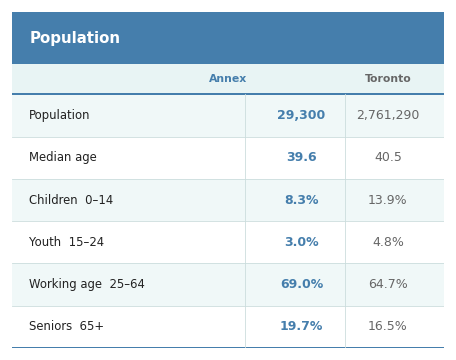

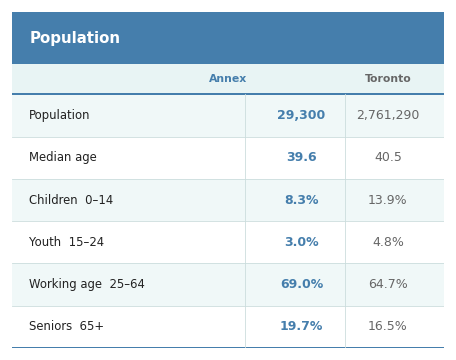

In [ ]:
#TODO: fix neighbourhood name centering
plot_population_table(hood, TORONTO)